# NLP  — *Cien años de soledad*

**Autor del notebook:** Josef Rodriguez

Esta versión está pensada para clase y presentación.  
Además del pipeline de NLP, incluye:

- secciones mejor estructuradas
- interpretación guiada de resultados
- bloques de conclusiones automáticas
- visualizaciones más limpias
- análisis narrativo por bloques
- red de personajes
- sentimiento y tópicos
- embeddings semánticos opcionales

> El texto se carga directamente desde tu repositorio de GitHub.


## Objetivos de aprendizaje

Al finalizar este notebook, el alumno debería poder:

1. cargar y limpiar una novela en español
2. construir métricas léxicas básicas
3. detectar temas con LDA
4. analizar personajes con reglas y NER
5. construir una red de coocurrencia
6. interpretar la evolución narrativa con NLP
7. discutir límites del NLP aplicado a literatura


In [1]:
# =========================
# 1. Instalación
# =========================
!pip install -q nltk spacy scikit-learn gensim wordcloud networkx matplotlib pandas numpy requests sentence-transformers


In [2]:
# =========================
# 2. Carga robusta de spaCy en español
# =========================
import sys
import subprocess
import spacy

MODEL_NAME = "es_core_news_sm"

try:
    nlp = spacy.load(MODEL_NAME)
    print(f"Modelo '{MODEL_NAME}' cargado correctamente.")
except Exception:
    print(f"No se encontró '{MODEL_NAME}'. Descargándolo...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", MODEL_NAME])
    nlp = spacy.load(MODEL_NAME)
    print(f"Modelo '{MODEL_NAME}' descargado y cargado.")


Modelo 'es_core_news_sm' cargado correctamente.


In [3]:
# =========================
# 3. Imports
# =========================
import re
import unicodedata
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from collections import Counter, defaultdict
from itertools import combinations

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud


In [4]:
# =========================
# 4. Recursos NLTK
# =========================
nltk.download("punkt")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/josefrodriguez/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/josefrodriguez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 5. Cargar el libro desde GitHub

In [5]:
RAW_URL = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/cien-anios-de-soledad.txt"

response = requests.get(RAW_URL, timeout=30)
response.raise_for_status()

raw_text = response.text

print("Vista previa:")
print(raw_text[:1200])
print("\nLongitud total del texto:", len(raw_text))


Vista previa:
Gabriel García Márquez 



Cien años de soledad 



EDITADO POR "EDICIONES LA CUEVA" 



Para J omi García Ascot 
y María Luisa Elio 



Cien años de soledad 



Gabriel García Márquez 



Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de 
recordar aquella tarde remota en que su padre lo llevó a conocer el hielo. Macondo era entonces 
una aldea de veinte casas de barro y cañabrava construidas a la orilla de un río de aguas diáfanas 
que se precipitaban por un lecho de piedras pulidas, blancas y enormes como huevos 
prehistóricos. El mundo era tan reciente, que muchas cosas carecían de nombre, y para 
mencionarlas había que señalarías con el dedo. Todos los años, por el mes de marzo, una familia 
de gitanos desarrapados plantaba su carpa cerca de la aldea, y con un grande alboroto de pitos y 
timbales daban a conocer los nuevos inventos. Primero llevaron el imán. Un gitano corpulento, de 
barba montaraz y manos de gorrión, que se

## 6. Limpieza y normalización

La normalización reduce ruido y facilita:
- conteos
- matching de personajes
- topic modeling
- sentimiento básico


In [6]:
spanish_stopwords = set(stopwords.words("spanish"))

custom_stopwords = {
    "si", "aqui", "alli", "años", "año", "vez", "veces"
}

all_stopwords = spanish_stopwords.union(custom_stopwords)

def strip_accents(text: str) -> str:
    return "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )

def clean_text_basic(text: str) -> str:
    text = text.replace("\r", "\n")
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

def normalize_text(text: str) -> str:
    text = text.lower()
    text = strip_accents(text)
    text = re.sub(r"[^a-zñ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

text = clean_text_basic(raw_text)
normalized_text = normalize_text(text)

print(normalized_text[:600])


gabriel garcia marquez cien anos de soledad editado por ediciones la cueva para j omi garcia ascot y maria luisa elio cien anos de soledad gabriel garcia marquez muchos anos despues frente al peloton de fusilamiento el coronel aureliano buendia habia de recordar aquella tarde remota en que su padre lo llevo a conocer el hielo macondo era entonces una aldea de veinte casas de barro y canabrava construidas a la orilla de un rio de aguas diafanas que se precipitaban por un lecho de piedras pulidas blancas y enormes como huevos prehistoricos el mundo era tan reciente que muchas cosas carecian de n


In [7]:
tokens = word_tokenize(normalized_text, language="spanish")

tokens_clean = [
    tok for tok in tokens
    if tok not in all_stopwords and len(tok) > 2
]

print("Primeros tokens limpios:", tokens_clean[:40])
print("Cantidad de tokens limpios:", len(tokens_clean))
print("Vocabulario único:", len(set(tokens_clean)))


Primeros tokens limpios: ['gabriel', 'garcia', 'marquez', 'cien', 'anos', 'soledad', 'editado', 'ediciones', 'cueva', 'omi', 'garcia', 'ascot', 'maria', 'luisa', 'elio', 'cien', 'anos', 'soledad', 'gabriel', 'garcia', 'marquez', 'anos', 'despues', 'frente', 'peloton', 'fusilamiento', 'coronel', 'aureliano', 'buendia', 'habia', 'recordar', 'aquella', 'tarde', 'remota', 'padre', 'llevo', 'conocer', 'hielo', 'macondo', 'entonces']
Cantidad de tokens limpios: 4691
Vocabulario único: 2533


## 7. Frecuencia de palabras

In [8]:
freq = Counter(tokens_clean)
top_words_df = pd.DataFrame(freq.most_common(30), columns=["word", "count"])
top_words_df


,word,count
0,jose,61
1,arcadio,61
2,buendia,60
3,habia,46
4,ursula,43
5,mas,39
6,anos,31
7,melquiades,24
8,casa,23
9,entonces,21


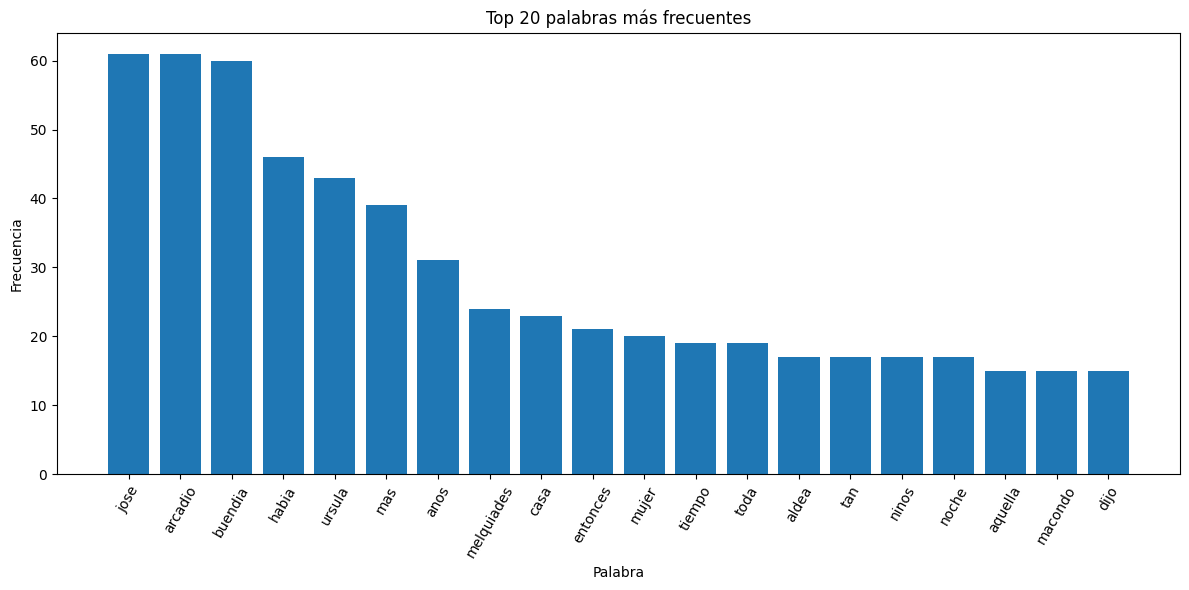

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(top_words_df["word"][:20], top_words_df["count"][:20])
plt.xticks(rotation=60)
plt.title("Top 20 palabras más frecuentes")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


In [10]:
def summarize_top_words(df, n=10):
    top = df.head(n)
    print("Conclusión automática:")
    print(
        "Las palabras más frecuentes sugieren cuáles son los ejes léxicos dominantes del texto. "
        "Este resultado debe interpretarse junto con el contexto narrativo, porque una alta frecuencia "
        "no siempre implica relevancia temática profunda."
    )
    print("\nTop términos:")
    print(", ".join(top["word"].tolist()))

summarize_top_words(top_words_df, n=10)


Conclusión automática:
Las palabras más frecuentes sugieren cuáles son los ejes léxicos dominantes del texto. Este resultado debe interpretarse junto con el contexto narrativo, porque una alta frecuencia no siempre implica relevancia temática profunda.

Top términos:
jose, arcadio, buendia, habia, ursula, mas, anos, melquiades, casa, entonces


## 8. WordCloud

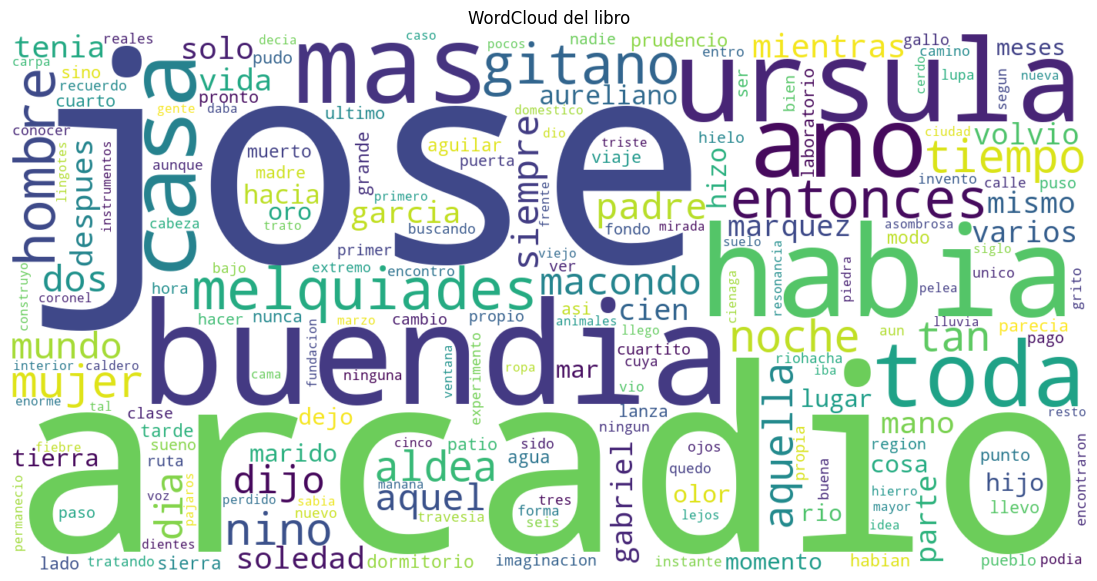

In [11]:
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    collocations=False
).generate(" ".join(tokens_clean))

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud del libro")
plt.show()


## 9. Bigramas y trigramas

In [12]:
def get_top_ngrams(texts, ngram_range=(2, 2), max_features=30):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words=list(all_stopwords),
        max_features=max_features
    )
    X = vectorizer.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        "ngram": vocab,
        "count": counts
    }).sort_values("count", ascending=False)

    return df

bigram_df = get_top_ngrams([normalized_text], ngram_range=(2, 2), max_features=30)
trigram_df = get_top_ngrams([normalized_text], ngram_range=(3, 3), max_features=30)

print("TOP BIGRAMAS")
display(bigram_df.head(20))

print("\nTOP TRIGRAMAS")
display(trigram_df.head(20))


TOP BIGRAMAS


,ngram,count
17,jose arcadio,61
4,arcadio buendia,54
15,garcia marquez,12
13,gabriel garcia,12
6,cien anos,12
1,anos soledad,12
22,soledad gabriel,11
20,prudencio aguilar,8
28,todas partes,6
26,toda clase,6



TOP TRIGRAMAS


,ngram,count
15,jose arcadio buendia,54
7,cien anos soledad,12
14,gabriel garcia marquez,12
28,soledad gabriel garcia,11
0,anos soledad gabriel,11
9,coronel aureliano buendia,4
5,aureliano buendia volvio,2
3,arcadio buendia pago,2
2,arcadio buendia mientras,2
27,primer aureliano buendia,2


In [13]:
print("Conclusión automática:")
print(
    "Los n-gramas permiten detectar asociaciones frecuentes entre palabras. "
    "En literatura, esto ayuda a localizar nombres compuestos, fórmulas narrativas "
    "y expresiones recurrentes que no se observan bien con palabras aisladas."
)


Conclusión automática:
Los n-gramas permiten detectar asociaciones frecuentes entre palabras. En literatura, esto ayuda a localizar nombres compuestos, fórmulas narrativas y expresiones recurrentes que no se observan bien con palabras aisladas.


## 10. Segmentación en bloques narrativos

Si el archivo no tiene capítulos bien marcados, una estrategia robusta es dividir el texto en bloques de oraciones.


In [14]:
sentences = sent_tokenize(text, language="spanish")

def split_into_chunks(sentences, chunk_size=25):
    chunks = []
    for i in range(0, len(sentences), chunk_size):
        chunk = " ".join(sentences[i:i+chunk_size])
        if len(chunk.strip()) > 0:
            chunks.append(chunk)
    return chunks

chunks = split_into_chunks(sentences, chunk_size=25)

print("Número de oraciones:", len(sentences))
print("Número de bloques:", len(chunks))
print("\nPrimer bloque:")
print(chunks[0][:1200])


Número de oraciones: 352
Número de bloques: 15

Primer bloque:
Gabriel García Márquez 
Cien años de soledad 
EDITADO POR "EDICIONES LA CUEVA" 
Para J omi García Ascot 
y María Luisa Elio 
Cien años de soledad 
Gabriel García Márquez 
Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de 
recordar aquella tarde remota en que su padre lo llevó a conocer el hielo. Macondo era entonces 
una aldea de veinte casas de barro y cañabrava construidas a la orilla de un río de aguas diáfanas 
que se precipitaban por un lecho de piedras pulidas, blancas y enormes como huevos 
prehistóricos. El mundo era tan reciente, que muchas cosas carecían de nombre, y para 
mencionarlas había que señalarías con el dedo. Todos los años, por el mes de marzo, una familia 
de gitanos desarrapados plantaba su carpa cerca de la aldea, y con un grande alboroto de pitos y 
timbales daban a conocer los nuevos inventos. Primero llevaron el imán. Un gitano corpulento, de 
barba mont

## 11. Topic Modeling con LDA

In [15]:
vectorizer = CountVectorizer(
    stop_words=list(all_stopwords),
    max_df=0.95,
    min_df=2
)

X = vectorizer.fit_transform([normalize_text(c) for c in chunks])

lda = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    learning_method="batch"
)

lda.fit(X)


,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",6
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [16]:
def print_topics(model, feature_names, n_top_words=12):
    topics_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        topics_dict[f"topic_{topic_idx}"] = top_terms
        print(f"Topic {topic_idx + 1}: {', '.join(top_terms)}")
    return topics_dict

feature_names = vectorizer.get_feature_names_out()
topics_dict = print_topics(lda, feature_names, n_top_words=12)


Topic 1: olor, entonces, mas, dormitorio, modo, mujer, noche, casa, madre, toda, puerta, paso
Topic 2: buendia, jose, arcadio, anos, melquiades, mas, dos, ursula, mano, garcia, casa, reales
Topic 3: ursula, jose, arcadio, mujer, casa, tan, hielo, cola, despues, dijo, entonces, primer
Topic 4: buendia, jose, arcadio, aguilar, prudencio, lanza, ursula, noche, iguanas, gallera, volvio, dijo
Topic 5: buendia, mas, jose, arcadio, ursula, melquiades, anos, gitanos, aldea, aquella, macondo, siempre
Topic 6: buendia, arcadio, jose, ursula, anos, ninos, varios, toda, dejo, dijo, padre, punto


In [17]:
topic_distribution = lda.transform(X)
dominant_topic = topic_distribution.argmax(axis=1)

topic_df = pd.DataFrame({
    "chunk_id": range(len(chunks)),
    "dominant_topic": dominant_topic
})

topic_df.head()


,chunk_id,dominant_topic
0,0,1
1,1,5
2,2,4
3,3,4
4,4,4


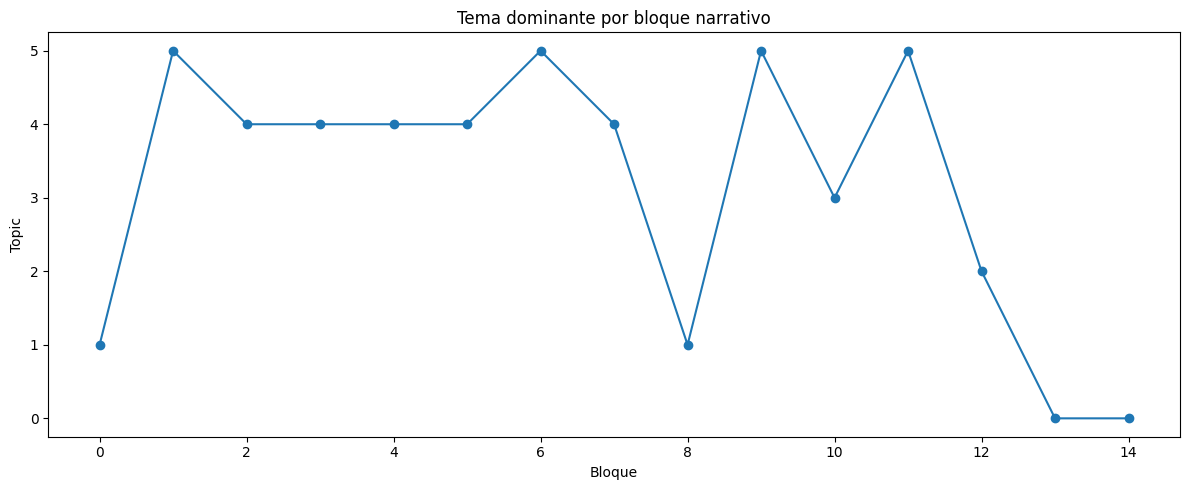

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(topic_df["chunk_id"], topic_df["dominant_topic"], marker="o")
plt.title("Tema dominante por bloque narrativo")
plt.xlabel("Bloque")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


In [19]:
def summarize_topics(topics_dict):
    print("Conclusión automática:")
    print(
        "Los topics no deben interpretarse como categorías perfectas, sino como agrupaciones estadísticas "
        "de términos que tienden a aparecer juntos. En una novela, suelen capturar núcleos como familia, "
        "guerra, memoria, muerte, religión o espacio doméstico."
    )
    print("\nResumen de topics:")
    for k, v in topics_dict.items():
        print(f"{k}: {', '.join(v[:6])}")

summarize_topics(topics_dict)


Conclusión automática:
Los topics no deben interpretarse como categorías perfectas, sino como agrupaciones estadísticas de términos que tienden a aparecer juntos. En una novela, suelen capturar núcleos como familia, guerra, memoria, muerte, religión o espacio doméstico.

Resumen de topics:
topic_0: olor, entonces, mas, dormitorio, modo, mujer
topic_1: buendia, jose, arcadio, anos, melquiades, mas
topic_2: ursula, jose, arcadio, mujer, casa, tan
topic_3: buendia, jose, arcadio, aguilar, prudencio, lanza
topic_4: buendia, mas, jose, arcadio, ursula, melquiades
topic_5: buendia, arcadio, jose, ursula, anos, ninos


## 12. Evolución temática completa

In [20]:
topic_prob_df = pd.DataFrame(
    topic_distribution,
    columns=[f"topic_{i}" for i in range(topic_distribution.shape[1])]
)
topic_prob_df["chunk_id"] = range(len(topic_prob_df))
topic_prob_df.head()


,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,chunk_id
0,0.000730,0.996343,0.000731,0.000730,0.000733,0.000733,0
1,0.000750,0.000753,0.000750,0.000750,0.000753,0.996243,1
2,0.000936,0.000938,0.000936,0.000937,0.995315,0.000939,2
3,0.000653,0.000653,0.000652,0.000652,0.996737,0.000654,3
4,0.084958,0.000777,0.000774,0.000774,0.911939,0.000778,4


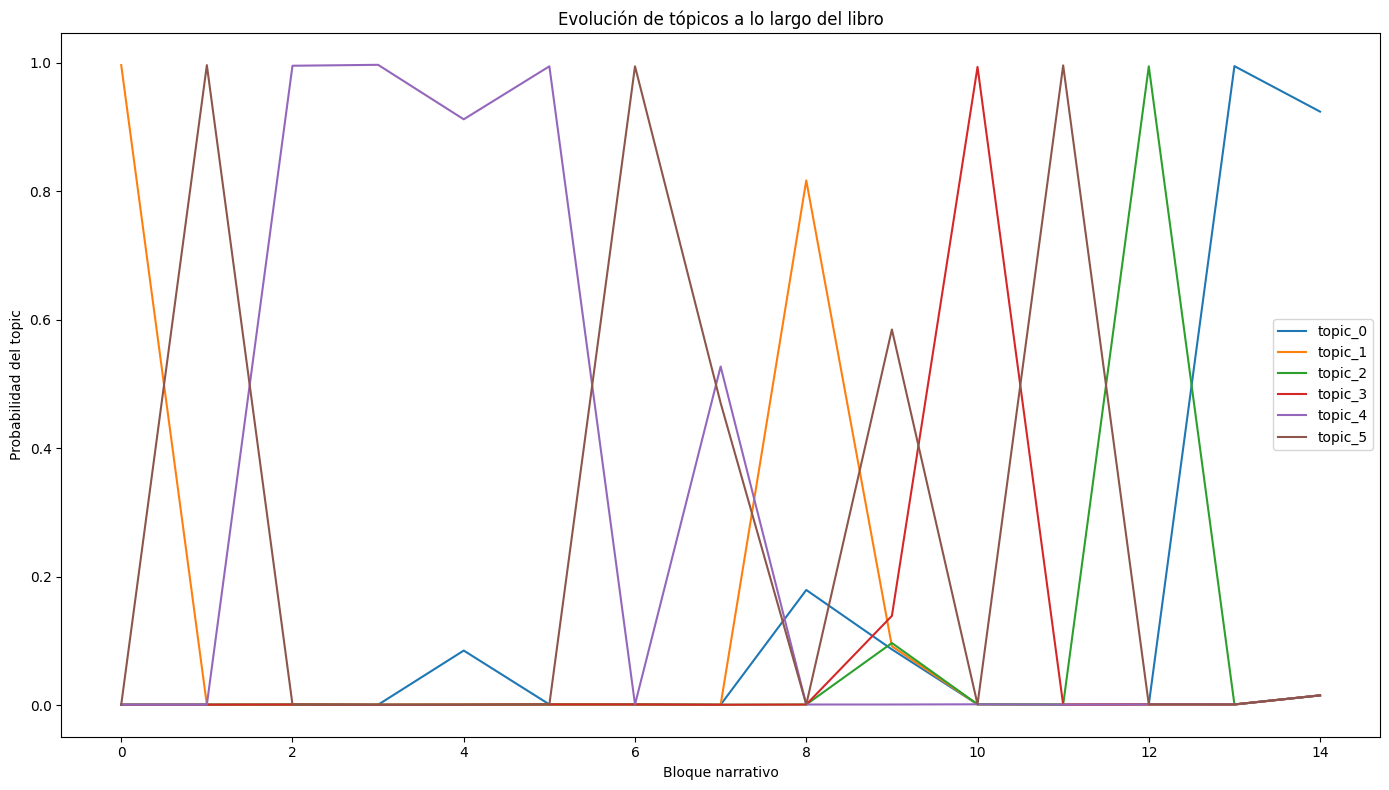

In [21]:
plt.figure(figsize=(14, 8))
for col in [c for c in topic_prob_df.columns if c.startswith("topic_")]:
    plt.plot(topic_prob_df["chunk_id"], topic_prob_df[col], label=col)

plt.title("Evolución de tópicos a lo largo del libro")
plt.xlabel("Bloque narrativo")
plt.ylabel("Probabilidad del topic")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Named Entity Recognition con spaCy

In [22]:
doc = nlp(text[:200000])

persons = [ent.text.strip() for ent in doc.ents if ent.label_ == "PER"]
person_freq = Counter(persons)

person_df = pd.DataFrame(person_freq.most_common(30), columns=["personaje", "menciones"])
person_df.head(20)


,personaje,menciones
0,José Arcadio Buendía,24
1,Melquíades,17
2,Gabriel García Márquez,11
3,José Arcadio,10
4,Prudencio Aguilar,7
5,Aureliano Buendía,6
6,Buendía,5
7,Aureliano,5
8,José Arcadio Buendia,3
9,Francis Drake,3


In [23]:
print("Conclusión automática:")
print(
    "El NER sirve como primer acercamiento, pero en literatura puede fallar por nombres repetidos, "
    "apodos, ambigüedad y estructuras genealógicas complejas. Por eso conviene complementarlo con reglas manuales."
)


Conclusión automática:
El NER sirve como primer acercamiento, pero en literatura puede fallar por nombres repetidos, apodos, ambigüedad y estructuras genealógicas complejas. Por eso conviene complementarlo con reglas manuales.


## 14. Lista curada de personajes y alias

In [24]:
character_aliases = {
    "jose_arcadio_buendia": ["jose arcadio buendia"],
    "ursula": ["ursula", "ursula iguaran"],
    "coronel_aureliano_buendia": ["coronel aureliano buendia", "aureliano buendia"],
    "jose_arcadio": ["jose arcadio"],
    "amaranta": ["amaranta"],
    "rebeca": ["rebeca"],
    "remedios": ["remedios", "remedios la bella"],
    "melquiades": ["melquiades"],
    "arcadio": ["arcadio"],
    "fernanda": ["fernanda", "fernanda del carpio"],
    "renata_remedios": ["renata remedios", "meme"],
    "mauricio_babilonia": ["mauricio babilonia"],
    "petra_cotes": ["petra cotes"],
    "santa_sofia_de_la_piedad": ["santa sofia de la piedad"]
}

def count_aliases(text_norm: str, aliases_dict: dict) -> dict:
    counts = {}
    for canonical, aliases in aliases_dict.items():
        total = 0
        for alias in aliases:
            alias_norm = normalize_text(alias)
            total += len(re.findall(r"\b" + re.escape(alias_norm) + r"\b", text_norm))
        counts[canonical] = total
    return counts

book_norm = normalize_text(text)
character_counts = count_aliases(book_norm, character_aliases)

character_counts_df = pd.DataFrame(
    sorted(character_counts.items(), key=lambda x: x[1], reverse=True),
    columns=["personaje", "menciones"]
)

character_counts_df


,personaje,menciones
0,jose_arcadio,61
1,arcadio,61
2,jose_arcadio_buendia,54
3,ursula,43
4,melquiades,24
5,coronel_aureliano_buendia,10
6,amaranta,0
7,rebeca,0
8,remedios,0
9,fernanda,0


## 15. Evolución de personajes por bloque

In [25]:
chunk_counts = []

for idx, chunk in enumerate(chunks):
    chunk_norm = normalize_text(chunk)
    row = {"chunk_id": idx}
    row.update(count_aliases(chunk_norm, character_aliases))
    chunk_counts.append(row)

char_timeline_df = pd.DataFrame(chunk_counts)
char_timeline_df.head()


,chunk_id,jose_arcadio_buendia,ursula,coronel_aureliano_buendia,jose_arcadio,amaranta,rebeca,remedios,melquiades,arcadio,fernanda,renata_remedios,mauricio_babilonia,petra_cotes,santa_sofia_de_la_piedad
0,0,4,2,2,4,0,0,0,6,4,0,0,0,0,0
1,1,5,2,0,5,0,0,0,2,5,0,0,0,0,0
2,2,4,4,0,5,0,0,0,5,5,0,0,0,0,0
3,3,5,5,0,5,0,0,0,4,5,0,0,0,0,0
4,4,4,1,1,4,0,0,0,1,4,0,0,0,0,0


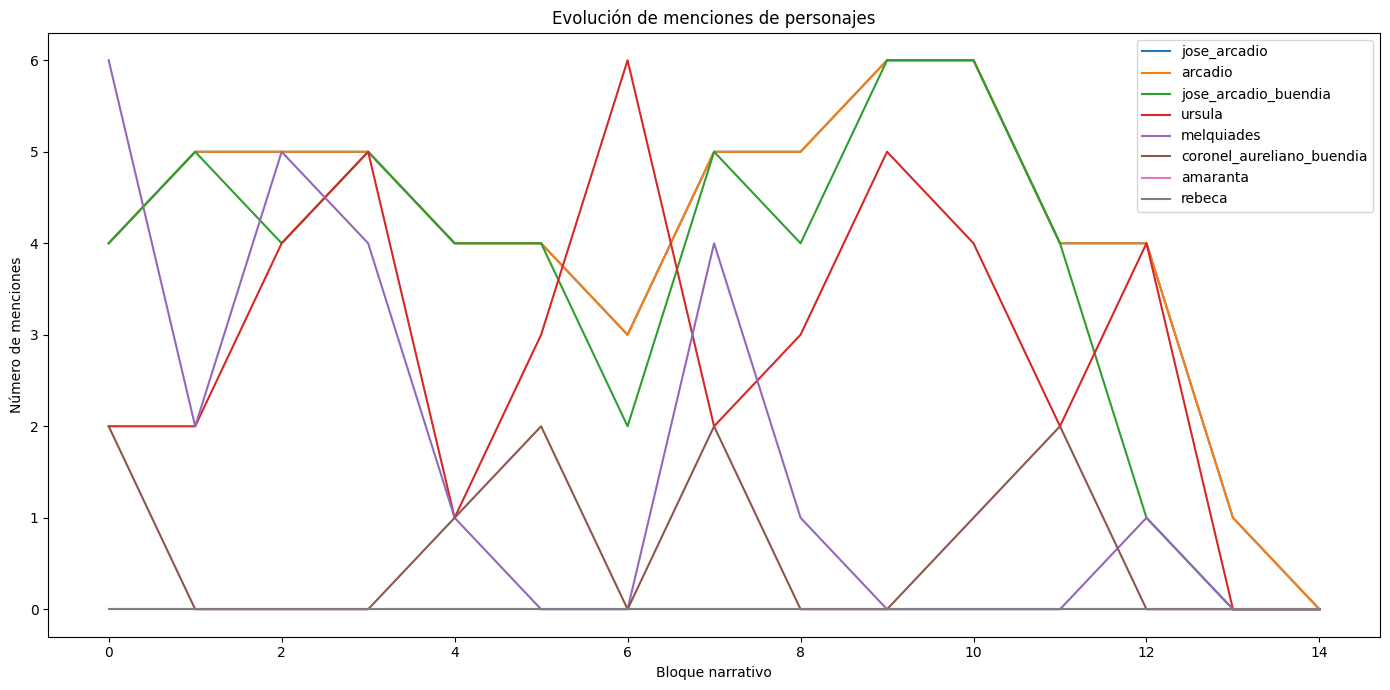

In [26]:
top_characters = character_counts_df.head(8)["personaje"].tolist()

plt.figure(figsize=(14, 7))
for ch in top_characters:
    plt.plot(char_timeline_df["chunk_id"], char_timeline_df[ch], label=ch)

plt.title("Evolución de menciones de personajes")
plt.xlabel("Bloque narrativo")
plt.ylabel("Número de menciones")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
def summarize_character_timeline(df_counts, top_chars):
    peaks = {}
    for ch in top_chars:
        peaks[ch] = int(df_counts[ch].idxmax())
    print("Conclusión automática:")
    print(
        "Este gráfico permite observar en qué tramos narrativos ciertos personajes ganan protagonismo. "
        "Los picos de mención no equivalen exactamente a importancia literaria, pero sí ayudan a visualizar presencia narrativa."
    )
    print("\nBloque de máximo protagonismo aproximado:")
    for ch, p in peaks.items():
        print(f"{ch}: bloque {p}")

summarize_character_timeline(char_timeline_df, top_characters)


Conclusión automática:
Este gráfico permite observar en qué tramos narrativos ciertos personajes ganan protagonismo. Los picos de mención no equivalen exactamente a importancia literaria, pero sí ayudan a visualizar presencia narrativa.

Bloque de máximo protagonismo aproximado:
jose_arcadio: bloque 9
arcadio: bloque 9
jose_arcadio_buendia: bloque 9
ursula: bloque 6
melquiades: bloque 0
coronel_aureliano_buendia: bloque 0
amaranta: bloque 0
rebeca: bloque 0


## 16. Red de coocurrencia de personajes

In [28]:
cooc = defaultdict(int)

for chunk in chunks:
    chunk_norm = normalize_text(chunk)
    present = []

    for canonical, aliases in character_aliases.items():
        found = False
        for alias in aliases:
            alias_norm = normalize_text(alias)
            if re.search(r"\b" + re.escape(alias_norm) + r"\b", chunk_norm):
                found = True
                break
        if found:
            present.append(canonical)

    for pair in combinations(sorted(set(present)), 2):
        cooc[pair] += 1

cooc_items = [(a, b, w) for (a, b), w in cooc.items() if w >= 2]
cooc_df = pd.DataFrame(cooc_items, columns=["source", "target", "weight"]).sort_values("weight", ascending=False)

cooc_df.head(20)


,source,target,weight
1,arcadio,jose_arcadio,14
2,arcadio,jose_arcadio_buendia,13
4,arcadio,ursula,13
9,jose_arcadio,jose_arcadio_buendia,13
11,jose_arcadio,ursula,13
13,jose_arcadio_buendia,ursula,13
3,arcadio,melquiades,8
10,jose_arcadio,melquiades,8
12,jose_arcadio_buendia,melquiades,8
14,melquiades,ursula,8


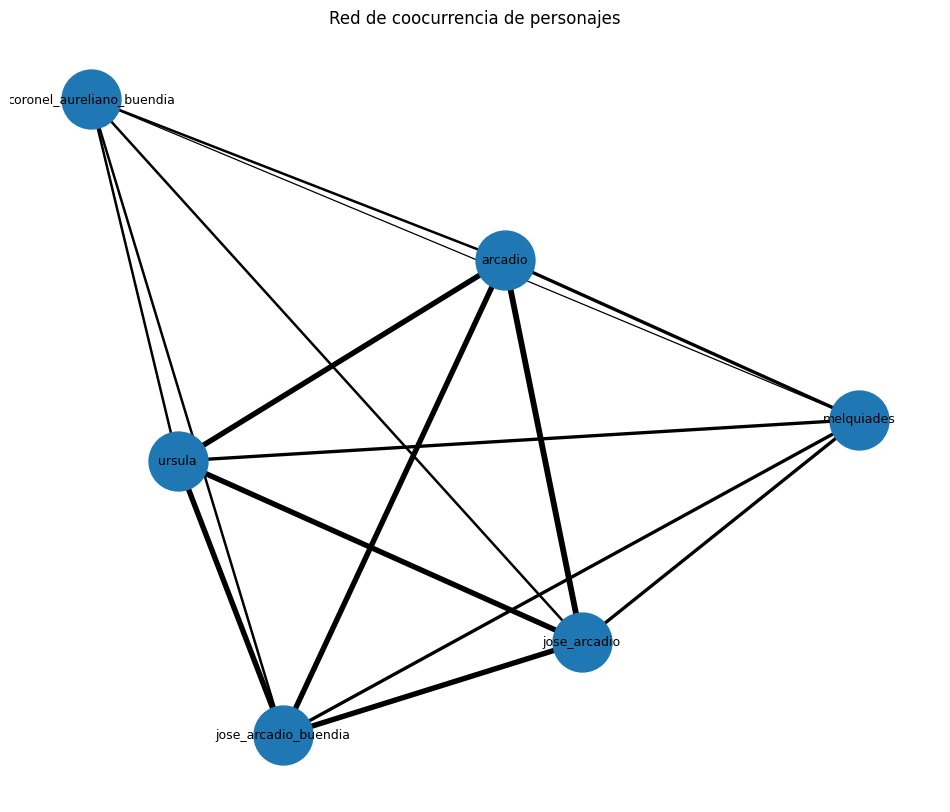

In [29]:
G = nx.Graph()
for _, row in cooc_df.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.8)
edge_widths = [G[u][v]["weight"] * 0.3 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=1800)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, width=edge_widths)

plt.title("Red de coocurrencia de personajes")
plt.axis("off")
plt.show()


## 17. Centralidad de personajes

In [30]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

centrality_df = pd.DataFrame({
    "personaje": list(G.nodes()),
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()]
}).sort_values(["degree_centrality", "betweenness_centrality"], ascending=False)

centrality_df


,personaje,degree_centrality,betweenness_centrality
0,arcadio,1.0,0.0
1,jose_arcadio,1.0,0.0
2,jose_arcadio_buendia,1.0,0.0
3,ursula,1.0,0.0
4,melquiades,1.0,0.0
5,coronel_aureliano_buendia,1.0,0.0


In [31]:
print("Conclusión automática:")
print(
    "La centralidad mide el rol estructural de cada personaje en la red. "
    "Degree centrality refleja cuántas conexiones tiene, mientras que betweenness "
    "mide cuánto actúa como puente entre grupos narrativos."
)


Conclusión automática:
La centralidad mide el rol estructural de cada personaje en la red. Degree centrality refleja cuántas conexiones tiene, mientras que betweenness mide cuánto actúa como puente entre grupos narrativos.


## 18. Lematización con spaCy

In [32]:
def lemmatize_text_spacy(text, max_chars=200000):
    text = text[:max_chars]
    doc = nlp(text)
    lemmas = []

    for token in doc:
        lemma = token.lemma_.lower().strip()
        lemma = strip_accents(lemma)
        if token.is_alpha and len(lemma) > 2 and lemma not in all_stopwords:
            lemmas.append(lemma)

    return lemmas

lemmas = lemmatize_text_spacy(text)
lemma_freq = Counter(lemmas)

lemma_df = pd.DataFrame(lemma_freq.most_common(30), columns=["lemma", "count"])
lemma_df.head(20)


,lemma,count
0,ser,92
1,haber,69
2,jose,61
3,arcadio,61
4,buendia,58
5,mas,39
6,ursula,37
7,aquel,33
8,ano,32
9,tener,31


## 19. Sentimiento por bloques

Aquí usamos un enfoque didáctico con un léxico manual.  
No sustituye un modelo avanzado, pero sí permite explicar el concepto.


In [33]:
positive_words = {
    "amor", "feliz", "alegria", "alegre", "belleza", "esperanza",
    "ternura", "placer", "gozo", "calma", "paz", "fortuna"
}

negative_words = {
    "muerte", "guerra", "soledad", "tristeza", "dolor", "sangre",
    "odio", "miedo", "violencia", "miseria", "desgracia", "llanto",
    "locura", "destruccion"
}

def sentiment_score(text_norm):
    toks = word_tokenize(text_norm, language="spanish")
    pos = sum(1 for t in toks if t in positive_words)
    neg = sum(1 for t in toks if t in negative_words)
    return pos - neg, pos, neg

sent_rows = []
for idx, chunk in enumerate(chunks):
    chunk_norm = normalize_text(chunk)
    score, pos, neg = sentiment_score(chunk_norm)
    sent_rows.append({
        "chunk_id": idx,
        "sentiment_score": score,
        "positive_count": pos,
        "negative_count": neg
    })

sentiment_df = pd.DataFrame(sent_rows)
sentiment_df.head()


,chunk_id,sentiment_score,positive_count,negative_count
0,0,-3,0,3
1,1,-2,0,2
2,2,-2,0,2
3,3,0,1,1
4,4,-4,0,4


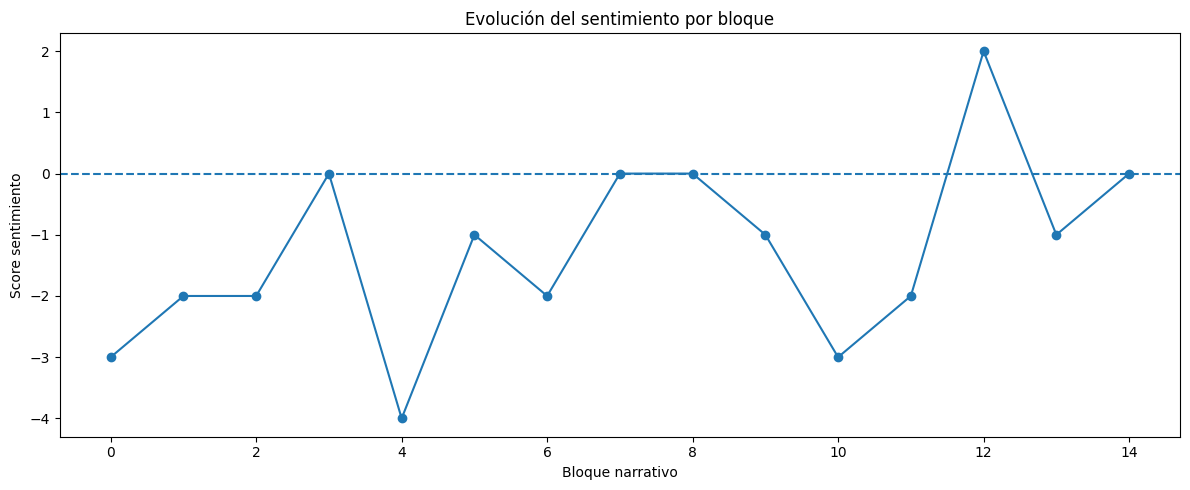

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(sentiment_df["chunk_id"], sentiment_df["sentiment_score"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Evolución del sentimiento por bloque")
plt.xlabel("Bloque narrativo")
plt.ylabel("Score sentimiento")
plt.tight_layout()
plt.show()


In [35]:
print("Conclusión automática:")
mean_sent = sentiment_df["sentiment_score"].mean()
trend = "más negativo" if mean_sent < 0 else "más positivo"
print(
    f"En promedio, el libro muestra un perfil léxico {trend} bajo este léxico manual. "
    "Esto debe leerse con cautela porque la literatura usa ironía, ambigüedad y simbolismo."
)


Conclusión automática:
En promedio, el libro muestra un perfil léxico más negativo bajo este léxico manual. Esto debe leerse con cautela porque la literatura usa ironía, ambigüedad y simbolismo.


## 20. Similitud de contexto entre personajes con bag-of-words

In [36]:
character_contexts = {}

for canonical, aliases in character_aliases.items():
    related_chunks = []
    for chunk in chunks:
        chunk_norm = normalize_text(chunk)
        found = False
        for alias in aliases:
            alias_norm = normalize_text(alias)
            if re.search(r"\b" + re.escape(alias_norm) + r"\b", chunk_norm):
                found = True
                break
        if found:
            related_chunks.append(chunk_norm)
    character_contexts[canonical] = " ".join(related_chunks)

context_vectorizer = CountVectorizer(
    stop_words=list(all_stopwords),
    max_features=1000
)

char_names = list(character_contexts.keys())
char_matrix = context_vectorizer.fit_transform([character_contexts[ch] for ch in char_names])

sim_matrix = cosine_similarity(char_matrix)
sim_df = pd.DataFrame(sim_matrix, index=char_names, columns=char_names)
sim_df.round(2)


,jose_arcadio_buendia,ursula,coronel_aureliano_buendia,jose_arcadio,amaranta,rebeca,remedios,melquiades,arcadio,fernanda,renata_remedios,mauricio_babilonia,petra_cotes,santa_sofia_de_la_piedad
jose_arcadio_buendia,1.00,1.00,0.94,1.00,0.0,0.0,0.0,0.97,1.00,0.0,0.0,0.0,0.0,0.0
ursula,1.00,1.00,0.94,1.00,0.0,0.0,0.0,0.97,1.00,0.0,0.0,0.0,0.0,0.0
coronel_aureliano_buendia,0.94,0.94,1.00,0.94,0.0,0.0,0.0,0.90,0.94,0.0,0.0,0.0,0.0,0.0
jose_arcadio,1.00,1.00,0.94,1.00,0.0,0.0,0.0,0.96,1.00,0.0,0.0,0.0,0.0,0.0
amaranta,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
rebeca,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
remedios,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
melquiades,0.97,0.97,0.90,0.96,0.0,0.0,0.0,1.00,0.96,0.0,0.0,0.0,0.0,0.0
arcadio,1.00,1.00,0.94,1.00,0.0,0.0,0.0,0.96,1.00,0.0,0.0,0.0,0.0,0.0
fernanda,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0


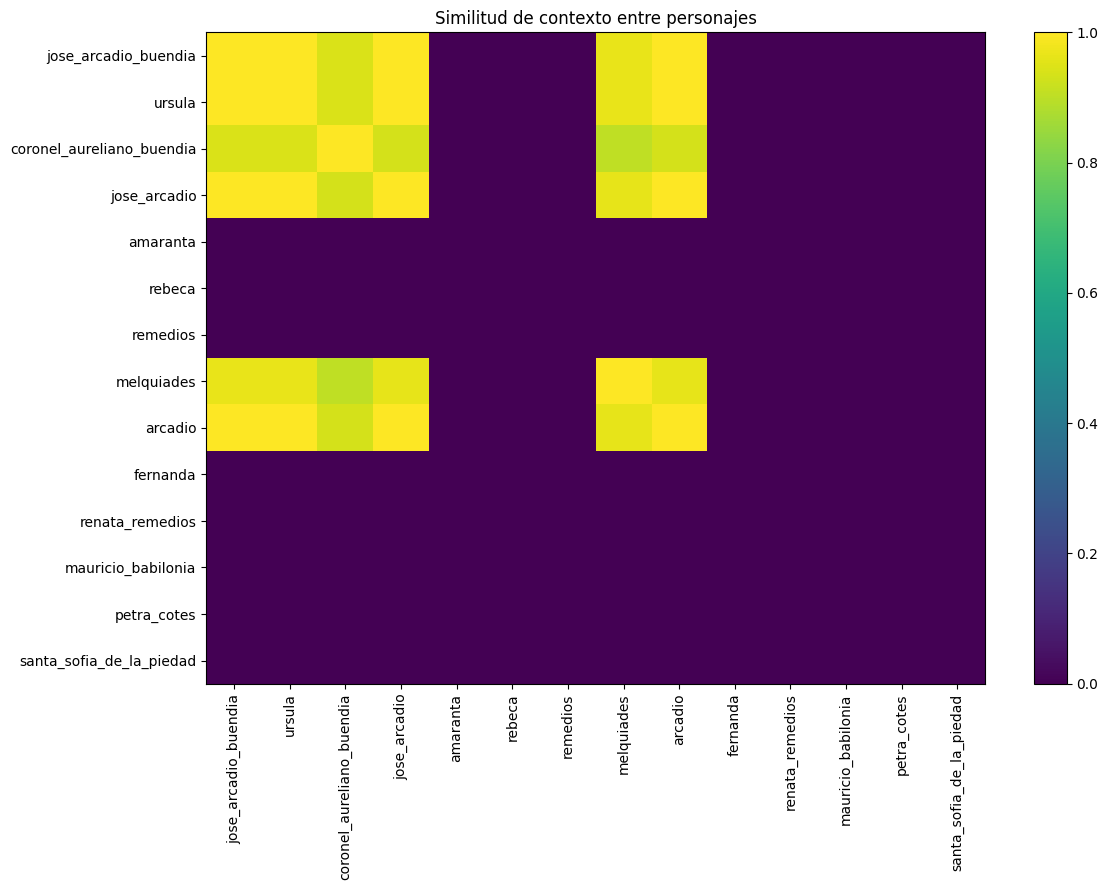

In [37]:
plt.figure(figsize=(12, 9))
plt.imshow(sim_df, aspect="auto")
plt.xticks(range(len(char_names)), char_names, rotation=90)
plt.yticks(range(len(char_names)), char_names)
plt.colorbar()
plt.title("Similitud de contexto entre personajes")
plt.tight_layout()
plt.show()


## 21. Embeddings modernos con Sentence Transformers (opcional)

In [38]:
USE_SENTENCE_TRANSFORMERS = True


In [39]:
if USE_SENTENCE_TRANSFORMERS:
    from sentence_transformers import SentenceTransformer

    st_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    st_embeddings = st_model.encode([
        character_contexts[ch] if character_contexts[ch].strip() else ch
        for ch in char_names
    ])

    st_sim = cosine_similarity(st_embeddings)
    st_sim_df = pd.DataFrame(st_sim, index=char_names, columns=char_names)
    display(st_sim_df.round(2))


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,jose_arcadio_buendia,ursula,coronel_aureliano_buendia,jose_arcadio,amaranta,rebeca,remedios,melquiades,arcadio,fernanda,renata_remedios,mauricio_babilonia,petra_cotes,santa_sofia_de_la_piedad
jose_arcadio_buendia,1.00,1.00,1.00,1.00,0.35,0.23,0.11,1.00,1.00,0.34,0.20,0.33,0.13,0.40
ursula,1.00,1.00,1.00,1.00,0.35,0.23,0.11,1.00,1.00,0.34,0.20,0.33,0.13,0.40
coronel_aureliano_buendia,1.00,1.00,1.00,1.00,0.35,0.23,0.11,1.00,1.00,0.34,0.20,0.33,0.13,0.40
jose_arcadio,1.00,1.00,1.00,1.00,0.35,0.23,0.11,1.00,1.00,0.34,0.20,0.33,0.13,0.40
amaranta,0.35,0.35,0.35,0.35,1.00,0.60,0.54,0.35,0.35,0.72,0.59,0.59,0.34,0.50
rebeca,0.23,0.23,0.23,0.23,0.60,1.00,0.45,0.23,0.23,0.50,0.61,0.41,0.24,0.42
remedios,0.11,0.11,0.11,0.11,0.54,0.45,1.00,0.11,0.11,0.45,0.54,0.29,0.31,0.23
melquiades,1.00,1.00,1.00,1.00,0.35,0.23,0.11,1.00,1.00,0.34,0.20,0.33,0.13,0.40
arcadio,1.00,1.00,1.00,1.00,0.35,0.23,0.11,1.00,1.00,0.34,0.20,0.33,0.13,0.40
fernanda,0.34,0.34,0.34,0.34,0.72,0.50,0.45,0.34,0.34,1.00,0.50,0.56,0.39,0.44


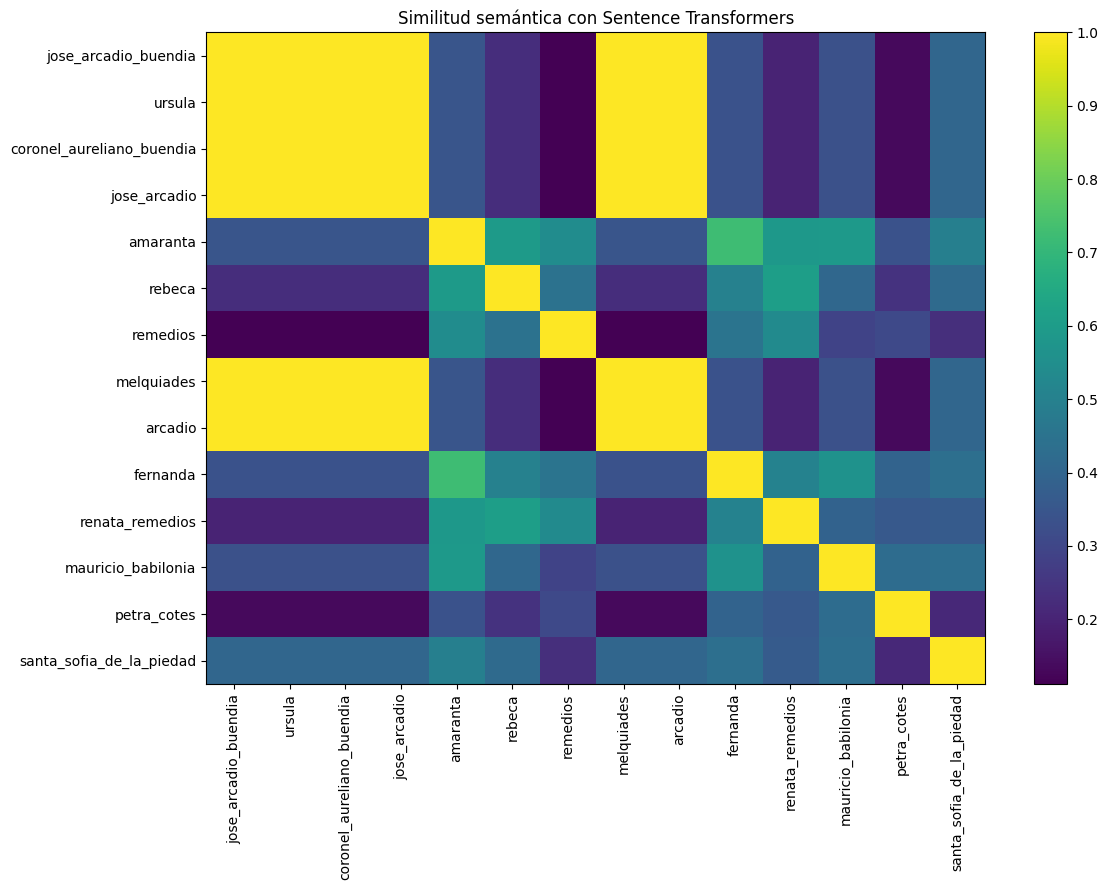

In [40]:
if USE_SENTENCE_TRANSFORMERS:
    plt.figure(figsize=(12, 9))
    plt.imshow(st_sim_df, aspect="auto")
    plt.xticks(range(len(char_names)), char_names, rotation=90)
    plt.yticks(range(len(char_names)), char_names)
    plt.colorbar()
    plt.title("Similitud semántica con Sentence Transformers")
    plt.tight_layout()
    plt.show()


## 22. Resumen 

In [41]:
print("=== TOP PALABRAS ===")
print(top_words_df.head(15).to_string(index=False))

print("\n=== TOP PERSONAJES ===")
print(character_counts_df.head(10).to_string(index=False))

print("\n=== CENTRALIDAD ===")
print(centrality_df.head(10).to_string(index=False))

print("\n=== TOPICS ===")
for k, v in topics_dict.items():
    print(k, "->", ", ".join(v[:8]))


=== TOP PALABRAS ===
      word  count
      jose     61
   arcadio     61
   buendia     60
     habia     46
    ursula     43
       mas     39
      anos     31
melquiades     24
      casa     23
  entonces     21
     mujer     20
    tiempo     19
      toda     19
     aldea     17
       tan     17

=== TOP PERSONAJES ===
                personaje  menciones
             jose_arcadio         61
                  arcadio         61
     jose_arcadio_buendia         54
                   ursula         43
               melquiades         24
coronel_aureliano_buendia         10
                 amaranta          0
                   rebeca          0
                 remedios          0
                 fernanda          0

=== CENTRALIDAD ===
                personaje  degree_centrality  betweenness_centrality
                  arcadio                1.0                     0.0
             jose_arcadio                1.0                     0.0
     jose_arcadio_buendia       

## 23. Cierre interpretativo

### Ideas 
- La novela puede analizarse como una secuencia narrativa segmentada en bloques.
- Los personajes no solo se estudian por frecuencia, sino por relaciones y centralidad.
- Los tópicos permiten detectar núcleos semánticos que acompañan la evolución de la historia.
- El sentimiento automático en literatura debe interpretarse con cautela.
- El NLP no reemplaza la crítica literaria, pero sí ofrece una capa cuantitativa poderosa.


